#### 5.4: Workshop 5 - Hierarchical Clustering for Crime Data Analysis

This week’s live workshop will provide students hands-on experience in applying Hierarchical Clustering to analyse crime data from the UK Police API. The session will guide students through collecting, preprocessing, and clustering crime-related data to identify high-risk and low-risk areas. By the end of the workshop, students will be able to map crime-prone regions using interactive geographic clustering techniques visually.

Students will explore the real-world application of unsupervised machine learning in crime analytics. They will analyse crime trends, process location-based crime reports, determine the optimal number of clusters using Dendrograms, and visualise crime clusters on an interactive crime heatmap. This exercise will not only reinforce their understanding of Hierarchical Clustering but also enhance their skills in data preprocessing, geospatial analysis, and visualization.

1. **Cell 3-4:** Preprocessing and feature preparation
2. **Cell 5-6:** Hierarchical clustering and optimal cluster selection
3. **Cell 7:** Risk assessment and zone classification
4. **Cell 8:** Interactive visualization
5. **Cell 9:** Results export and reporting
6. **Cell 10:** Validation framework

📌 Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25723 entries, 0 to 25722
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Month                  25723 non-null  object 
 1   Reported by            25723 non-null  object 
 2   Falls within           25723 non-null  object 
 3   Longitude              25723 non-null  float64
 4   Latitude               25723 non-null  float64
 5   Location               25723 non-null  object 
 6   LSOA code              25723 non-null  object 
 7   LSOA name              25723 non-null  object 
 8   Crime type             25723 non-null  object 
 9   Last outcome category  23731 non-null  object 
dtypes: float64(2), object(8)
memory usage: 2.0+ MB
None

📌 Sample Data:
     Month           Reported by          Falls within  Longitude   Latitude  \
0  2024-12  West Midlands Police  West Midlands Police  -1.849790  52.590937   
1  2024-12  West 

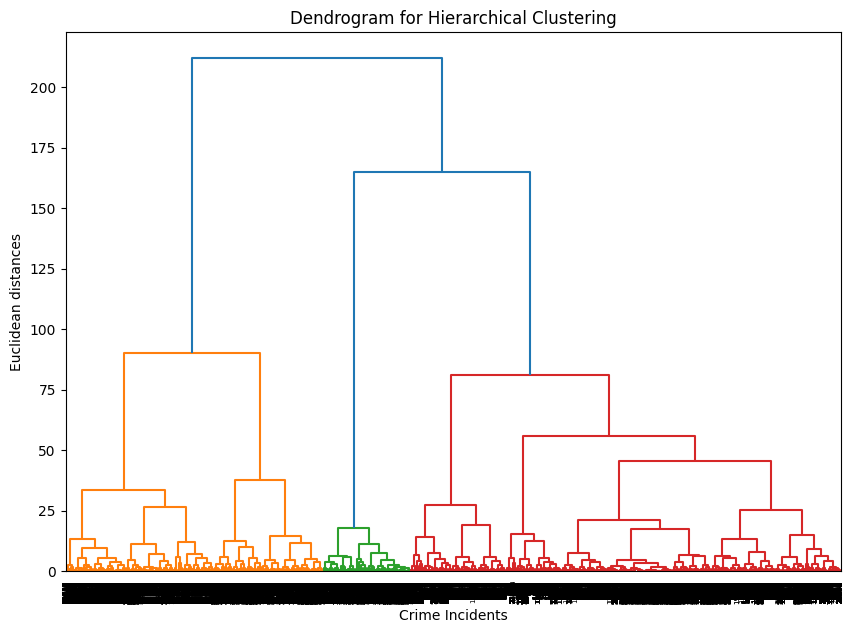


📌 Unique Clusters Assigned After Fix:
Cluster
247    548
246    383
150    295
23     286
249    249
      ... 
161     16
155     14
160      6
157      5
131      4
Name: count, Length: 313, dtype: int64

📌 Checking crime data for mapping...
    Latitude  Longitude  Cluster
0  52.590937  -1.849790      201
1  52.590937  -1.849790      201
2  52.588428  -1.848972      201
3  52.590937  -1.849790      201
4  52.593864  -1.847123      201
✅ Clustered data saved as 'west_midlands_crime_clusters.csv'

📌 Saving crime map...
✅ Crime map successfully saved as 'west_midlands_crime_map.html'. Opening in browser...


True

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import folium
from folium.plugins import MarkerCluster

# ---- Step 1: Load Crime Data ----
#file_path = "/mnt/data/2024-12-west-midlands-street.csv"
#df = pd.read_csv(file_path)
df = pd.read_csv('2024-12-west-midlands-street.csv')

# Drop unnecessary columns
df.drop(columns=['Crime ID', 'Context'], inplace=True, errors='ignore')

# ---- Step 2: Data Analysis ----
print("📌 Data Overview:")
print(df.info())

print("\n📌 Sample Data:")
print(df.head())

# Drop rows with missing latitude or longitude
df.dropna(subset=['Latitude', 'Longitude'], inplace=True)

# ---- Step 3: Data Transformation for Clustering ----
print("\n📌 Checking Crime Data for Clustering:")
print(df[['Latitude', 'Longitude']].describe())  # Ensure valid coordinates

# Select features for clustering
features = df[['Latitude', 'Longitude']]

# Standardize the features for better clustering
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# ---- Step 4: Hierarchical Clustering ----
print("\n📌 Running Hierarchical Clustering...")
linked = linkage(features_scaled, method='ward')

# Plot dendrogram to determine clusters
plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Crime Incidents")
plt.ylabel("Euclidean distances")
plt.show()

# Dynamically determine clusters based on distance threshold
max_distance = 0.8  # Reduce to merge more points into fewer clusters
#max_distance = 1  # Adjust as needed
df["Cluster"] = fcluster(linked, max_distance, criterion="distance")

# ---- Debug: Verify Clustering Success ----
print("\n📌 Unique Clusters Assigned After Fix:")
print(df["Cluster"].value_counts())  # Show how many points in each cluster

if df["Cluster"].nunique() < 2:
    print("❌ Clustering failed! Only one cluster detected. Try adjusting `max_distance`.")
    exit()

print("\n📌 Checking crime data for mapping...")
print(df[['Latitude', 'Longitude', 'Cluster']].head())

# ---- Step 5: Visualizing Crime Clusters on a Map ----
map_center = [52.4862, -1.8904]  # Birmingham, West Midlands
crime_map = folium.Map(location=map_center, zoom_start=12)

# Define a color palette for unique clusters
unique_clusters = df['Cluster'].nunique()
colors = sns.color_palette("husl", unique_clusters).as_hex()

# Add crime incidents to the map
marker_cluster = MarkerCluster().add_to(crime_map)

for idx, row in df.iterrows():
    folium.CircleMarker(
        location=(row["Latitude"], row["Longitude"]),
        radius=3,
        color=colors[row["Cluster"] % len(colors)],  # Assign unique colors
        fill=True,
        fill_color=colors[row["Cluster"] % len(colors)],
        fill_opacity=0.7
    ).add_to(marker_cluster)


# ---- Save Crime Clusters to CSV for Further Analysis ----
df.to_csv("west_midlands_crime_clusters.csv", index=False)
print("✅ Clustered data saved as 'west_midlands_crime_clusters.csv'")

# ---- Save and Open the Map ----
print("\n📌 Saving crime map...")
crime_map.save("west_midlands_crime_map.html")
print("✅ Crime map successfully saved as 'west_midlands_crime_map.html'. Opening in browser...")

import webbrowser
webbrowser.open("west_midlands_crime_map.html")


In [ ]:
# Cell 1: Import Required Libraries
"""
This cell imports all necessary libraries for:
- Data manipulation (pandas, numpy)
- Visualization (matplotlib, seaborn, folium)
- Machine learning (sklearn for preprocessing and clustering)
- Hierarchical clustering (scipy)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler # For feature scaling
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score # For cluster evaluation
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster # For hierarchical clustering
from scipy.spatial.distance import pdist
import folium # For interactive maps
from folium.plugins import MarkerCluster, HeatMap
import webbrowser
from collections import Counter

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries imported successfully!")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 NumPy version: {np.__version__}")

✅ All libraries imported successfully!
📦 Pandas version: 2.3.3
📦 NumPy version: 1.26.4


In [3]:
# Cell 2: Load Crime/Accident Data
"""
Step 1: Download accident datasets from public sources
- Source: UK Crime Data (can be adapted for Traffic Accident Reports)
- This example uses West Midlands street crime data as a proxy
- For actual traffic accidents, use data.gov.uk or similar sources
"""

# Load the dataset
file_path = '2024-12-west-midlands-street.csv'
df_raw = pd.read_csv(file_path)

# Display basic information
print("📌 DATASET OVERVIEW")
print("=" * 60)
print(f"Total records loaded: {len(df_raw):,}")
print(f"Total columns: {len(df_raw.columns)}")
print(f"\nColumn names:\n{df_raw.columns.tolist()}")

print("\n📌 FIRST 5 ROWS:")
print(df_raw.head())

print("\n📌 DATA TYPES:")
print(df_raw.dtypes)

print("\n📌 MISSING VALUES:")
missing_data = df_raw.isnull().sum()
print(missing_data[missing_data > 0])

print("\n📌 DATASET SHAPE:")
print(f"Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")

📌 DATASET OVERVIEW
Total records loaded: 25,723
Total columns: 12

Column names:
['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude', 'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type', 'Last outcome category', 'Context']

📌 FIRST 5 ROWS:
                                            Crime ID    Month  \
0  dd902792bf46f7628ccba46f3b0865aea254b938a3cfb2...  2024-12   
1  4a4ae24e23111e3f8a80b06f084365d1e9c3b144cb731f...  2024-12   
2  358b5bdd910e01c4aa02ddb8373acebade3634c6cee8d1...  2024-12   
3  afb1d39e0c2911486b98d5f92445d5ec536759275a9428...  2024-12   
4  192d4de96af0530c0ed75451abf4a321ecc7a9b903bbeb...  2024-12   

            Reported by          Falls within  Longitude   Latitude  \
0  West Midlands Police  West Midlands Police  -1.849790  52.590937   
1  West Midlands Police  West Midlands Police  -1.849790  52.590937   
2  West Midlands Police  West Midlands Police  -1.848972  52.588428   
3  West Midlands Police  West Midlands Police  -1.849790  52.

📌 PREPROCESSING STEPS

1️⃣ Missing values before cleaning:
   Latitude: 0
   Longitude: 0

2️⃣ Missing values after cleaning:
   Latitude: 0
   Longitude: 0
   Records remaining: 25,723

3️⃣ INCIDENT TYPE DISTRIBUTION:
Crime type
Violence and sexual offences    10573
Shoplifting                      2425
Vehicle crime                    2071
Anti-social behaviour            1992
Criminal damage and arson        1932
Other theft                      1686
Burglary                         1302
Public order                     1269
Drugs                             710
Other crime                       504
Possession of weapons             463
Robbery                           458
Theft from the person             235
Bicycle theft                     103
Name: count, dtype: int64


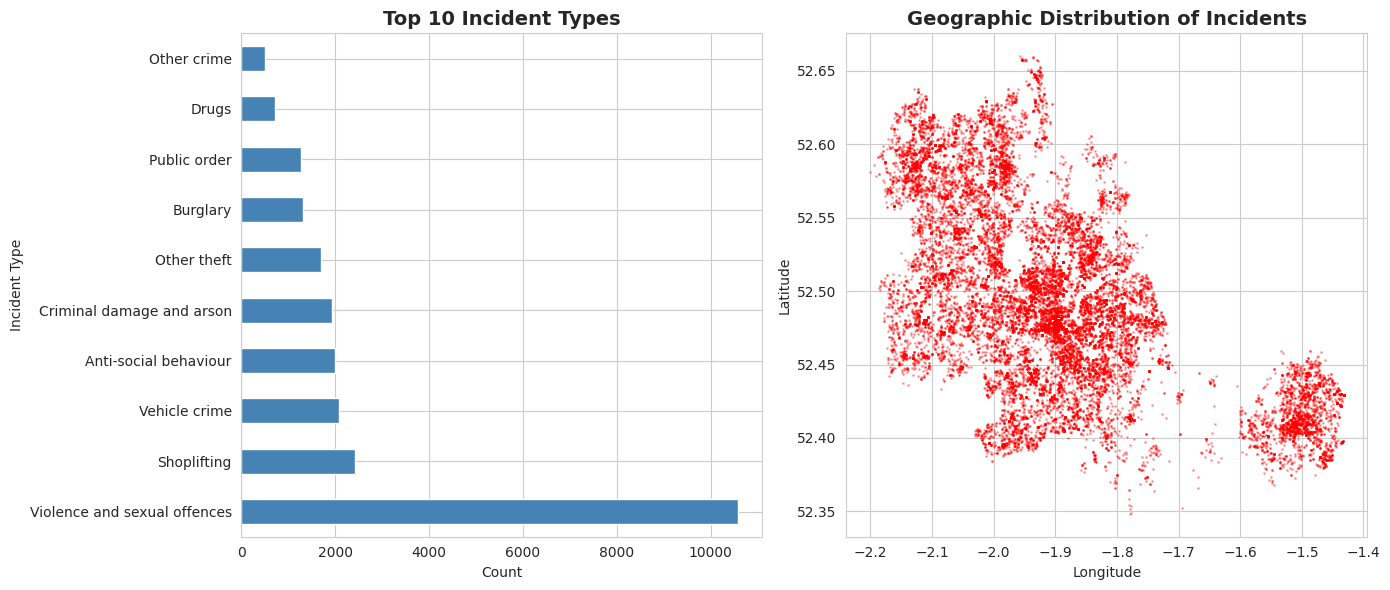


4️⃣ COORDINATE STATISTICS:
           Latitude     Longitude
count  25723.000000  25723.000000
mean      52.494062     -1.897834
std        0.062124      0.175096
min       52.348321     -2.200665
25%       52.447444     -2.012760
50%       52.484622     -1.916223
75%       52.537100     -1.830816
max       52.660066     -1.432151

✅ Preprocessing complete!
📊 Final dataset: 25,723 records with 10 features


In [4]:
# Cell 3: Preprocess Data and Select Relevant Features
"""
Step 2: Preprocess the data by selecting relevant features
- Remove unnecessary columns
- Handle missing values
- Extract location-based features (Latitude, Longitude)
- Analyze severity and type (Crime Type as proxy for accident severity)
"""

# Create a copy for preprocessing
df = df_raw.copy()

# Drop unnecessary columns
columns_to_drop = ['Crime ID', 'Context']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print("📌 PREPROCESSING STEPS")
print("=" * 60)

# Handle missing values for critical columns
print(f"\n1️⃣ Missing values before cleaning:")
print(f"   Latitude: {df['Latitude'].isnull().sum()}")
print(f"   Longitude: {df['Longitude'].isnull().sum()}")

# Drop rows with missing coordinates
df.dropna(subset=['Latitude', 'Longitude'], inplace=True)

print(f"\n2️⃣ Missing values after cleaning:")
print(f"   Latitude: {df['Latitude'].isnull().sum()}")
print(f"   Longitude: {df['Longitude'].isnull().sum()}")
print(f"   Records remaining: {len(df):,}")

# Analyze crime types (proxy for accident severity/type)
print("\n3️⃣ INCIDENT TYPE DISTRIBUTION:")
print(df['Crime type'].value_counts())

# Visualize incident distribution
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
crime_counts = df['Crime type'].value_counts().head(10)
crime_counts.plot(kind='barh', color='steelblue')
plt.title('Top 10 Incident Types', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Incident Type')
plt.tight_layout()

# Visualize geographic distribution
plt.subplot(1, 2, 2)
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.3, s=1, c='red')
plt.title('Geographic Distribution of Incidents', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

# Statistical summary of coordinates
print("\n4️⃣ COORDINATE STATISTICS:")
print(df[['Latitude', 'Longitude']].describe())

print("\n✅ Preprocessing complete!")
print(f"📊 Final dataset: {len(df):,} records with {len(df.columns)} features")

📌 FEATURE SCALING

1️⃣ Original Feature Statistics:
           Latitude     Longitude
count  25723.000000  25723.000000
mean      52.494062     -1.897834
std        0.062124      0.175096
min       52.348321     -2.200665
25%       52.447444     -2.012760
50%       52.484622     -1.916223
75%       52.537100     -1.830816
max       52.660066     -1.432151

2️⃣ Scaled Feature Statistics:
       Latitude_scaled  Longitude_scaled
count     2.572300e+04      2.572300e+04
mean      3.768200e-14      8.308955e-16
std       1.000019e+00      1.000019e+00
min      -2.346002e+00     -1.729545e+00
25%      -7.504180e-01     -6.563709e-01
50%      -1.519521e-01     -1.050229e-01
75%       6.927913e-01      3.827588e-01
max       2.672187e+00      2.659639e+00


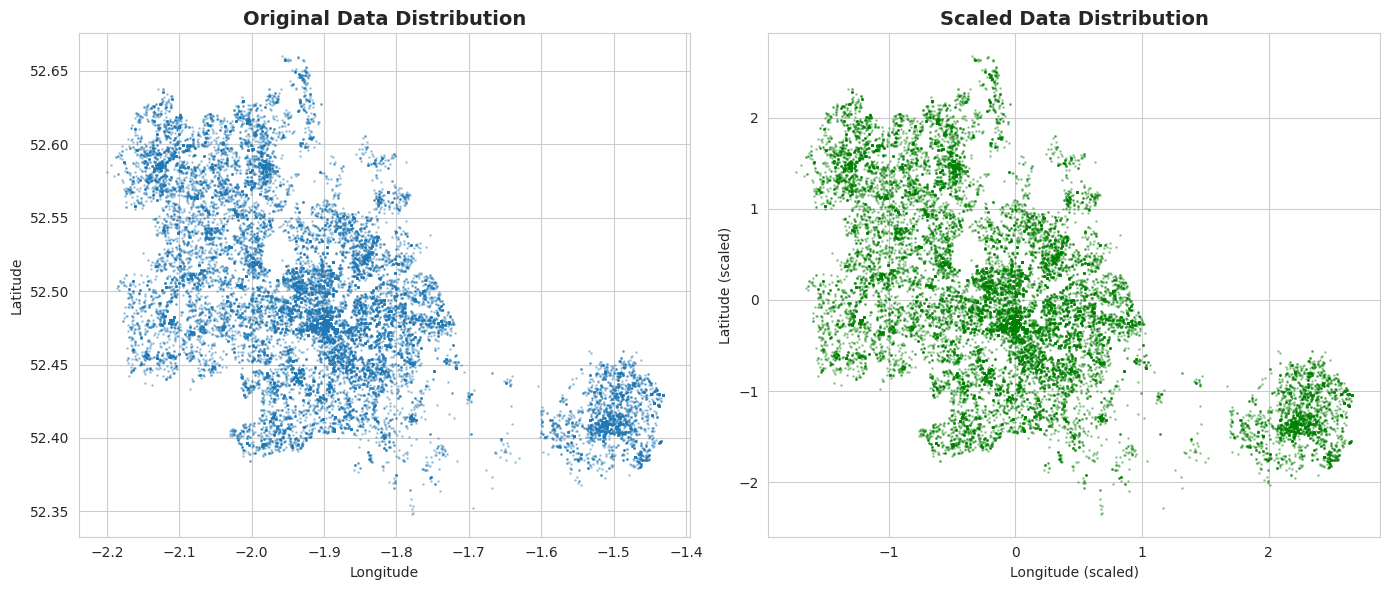


✅ Feature scaling complete!
📊 Scaled features shape: (25723, 2)


In [6]:
# Cell 4: Feature Scaling for Clustering
"""
Step 2 (continued): Prepare features for clustering
- Select coordinate features
- Standardize features to ensure equal weight
- Validate scaled data
"""

# Select features for clustering
features = df[['Latitude', 'Longitude']].copy()

print("📌 FEATURE SCALING")
print("=" * 60)

print("\n1️⃣ Original Feature Statistics:")
print(features.describe())

# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled_df = pd.DataFrame(features_scaled, columns=['Latitude_scaled', 'Longitude_scaled'])

print("\n2️⃣ Scaled Feature Statistics:")
print(features_scaled_df.describe())

# Visualize before and after scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original data
axes[0].scatter(features['Longitude'], features['Latitude'], alpha=0.3, s=1)
axes[0].set_title('Original Data Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Scaled data
axes[1].scatter(features_scaled_df['Longitude_scaled'], features_scaled_df['Latitude_scaled'], 
                alpha=0.3, s=1, c='green')
axes[1].set_title('Scaled Data Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitude (scaled)')
axes[1].set_ylabel('Latitude (scaled)')

plt.tight_layout()
plt.show()

print("\n✅ Feature scaling complete!")
print(f"📊 Scaled features shape: {features_scaled.shape}")

📌 HIERARCHICAL CLUSTERING

1️⃣ Computing hierarchical clustering...
   Using Ward linkage method
   Sample size for dendrogram: 5,000


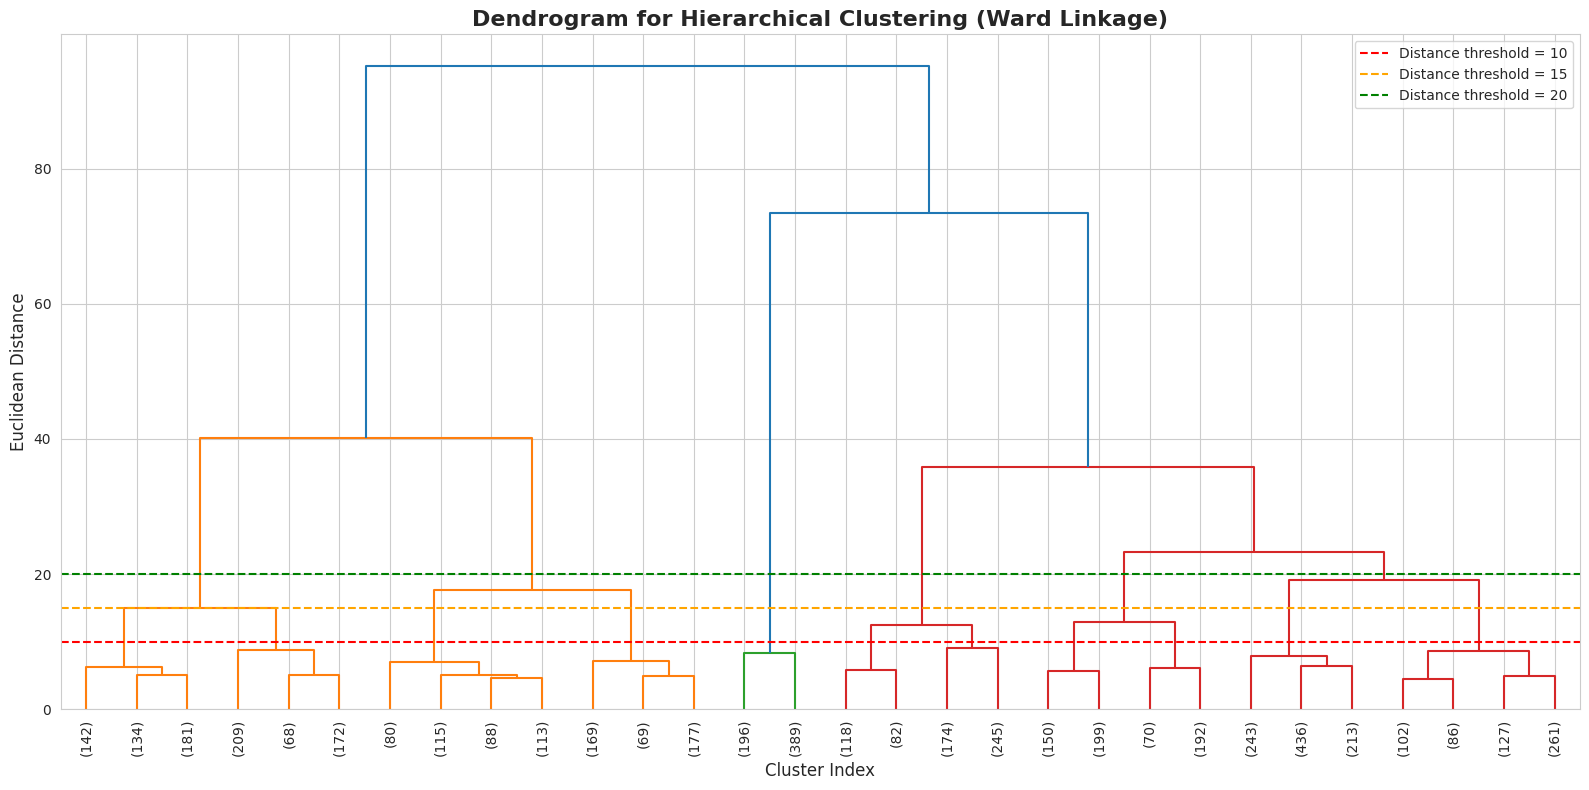


2️⃣ CLUSTER ANALYSIS AT DIFFERENT THRESHOLDS:
   Distance threshold  5 →  59 clusters
   Distance threshold 10 →  29 clusters
   Distance threshold 15 →  17 clusters
   Distance threshold 20 →  13 clusters
   Distance threshold 25 →  12 clusters
   Distance threshold 30 →   9 clusters

✅ Dendrogram analysis complete!
💡 TIP: Choose a distance threshold that balances detail and interpretability


In [7]:
# Cell 5: Apply Hierarchical Clustering and Dendrogram Analysis
"""
Step 3 & 4: Apply Hierarchical Clustering and Dendrogram Analysis
- Use Agglomerative Clustering (Ward linkage)
- Create dendrogram to visualize cluster hierarchy
- Determine optimal number of clusters
"""

print("📌 HIERARCHICAL CLUSTERING")
print("=" * 60)

# For large datasets, sample for dendrogram visualization
sample_size = min(5000, len(features_scaled))
sample_indices = np.random.choice(len(features_scaled), sample_size, replace=False)
features_sample = features_scaled[sample_indices]

print(f"\n1️⃣ Computing hierarchical clustering...")
print(f"   Using Ward linkage method")
print(f"   Sample size for dendrogram: {sample_size:,}")

# Perform hierarchical clustering
linked = linkage(features_scaled, method='ward')
linked_sample = linkage(features_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 8))
dendrogram(linked_sample, 
           truncate_mode='lastp',  # Show only last p merged clusters
           p=30,  # Show last 30 merges
           leaf_rotation=90,
           leaf_font_size=10)
plt.title("Dendrogram for Hierarchical Clustering (Ward Linkage)", 
          fontsize=16, fontweight='bold')
plt.xlabel("Cluster Index", fontsize=12)
plt.ylabel("Euclidean Distance", fontsize=12)
plt.axhline(y=10, color='r', linestyle='--', label='Distance threshold = 10')
plt.axhline(y=15, color='orange', linestyle='--', label='Distance threshold = 15')
plt.axhline(y=20, color='green', linestyle='--', label='Distance threshold = 20')
plt.legend()
plt.tight_layout()
plt.show()

# Analyze different distance thresholds
print("\n2️⃣ CLUSTER ANALYSIS AT DIFFERENT THRESHOLDS:")
thresholds = [5, 10, 15, 20, 25, 30]
for threshold in thresholds:
    clusters = fcluster(linked, threshold, criterion='distance')
    n_clusters = len(np.unique(clusters))
    print(f"   Distance threshold {threshold:2d} → {n_clusters:3d} clusters")

print("\n✅ Dendrogram analysis complete!")
print("💡 TIP: Choose a distance threshold that balances detail and interpretability")

📌 OPTIMAL CLUSTER SELECTION

1️⃣ SELECTED DISTANCE THRESHOLD: 15
   Number of clusters formed: 17

2️⃣ CLUSTERING QUALITY METRICS:
   Silhouette Score: 0.3597 (Range: -1 to 1, higher is better)
   Davies-Bouldin Index: 0.8477 (Lower is better)
   Calinski-Harabasz Score: 35956.76 (Higher is better)

3️⃣ CLUSTER SIZE DISTRIBUTION:
Cluster
1     2002
2     1621
3     1285
4     1623
5     2013
6     1082
7     1833
8     1367
9      845
10     943
11     355
12    1537
13    1478
14    2172
15    1277
16    2142
17    2148
Name: count, dtype: int64


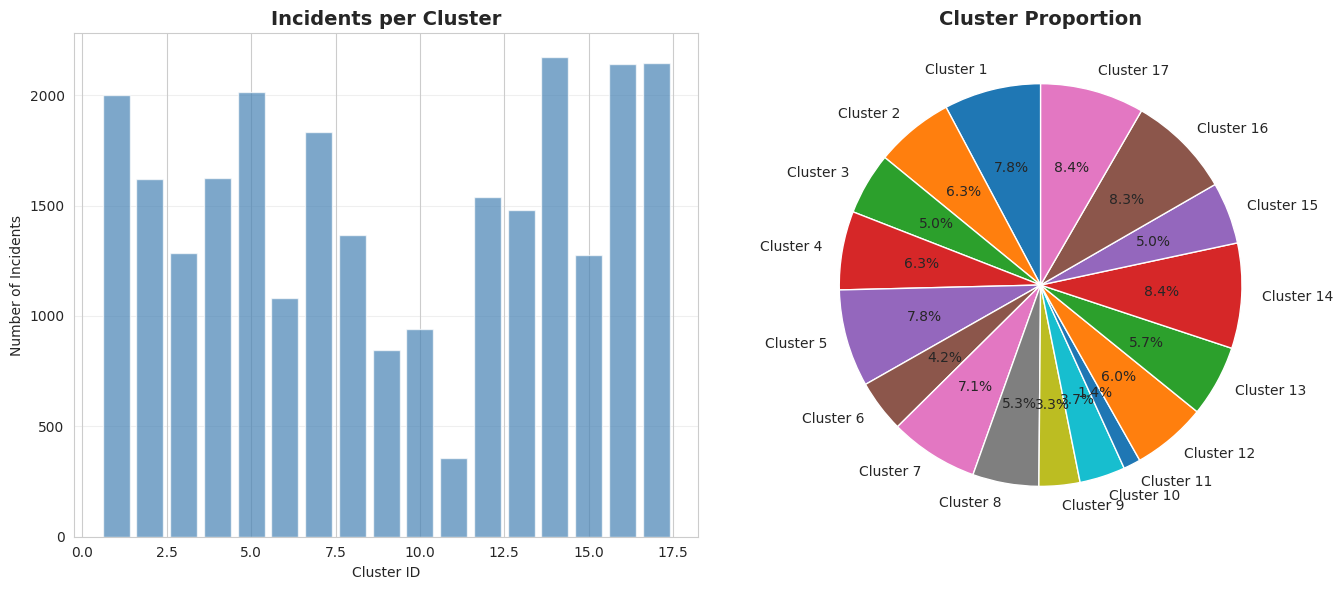

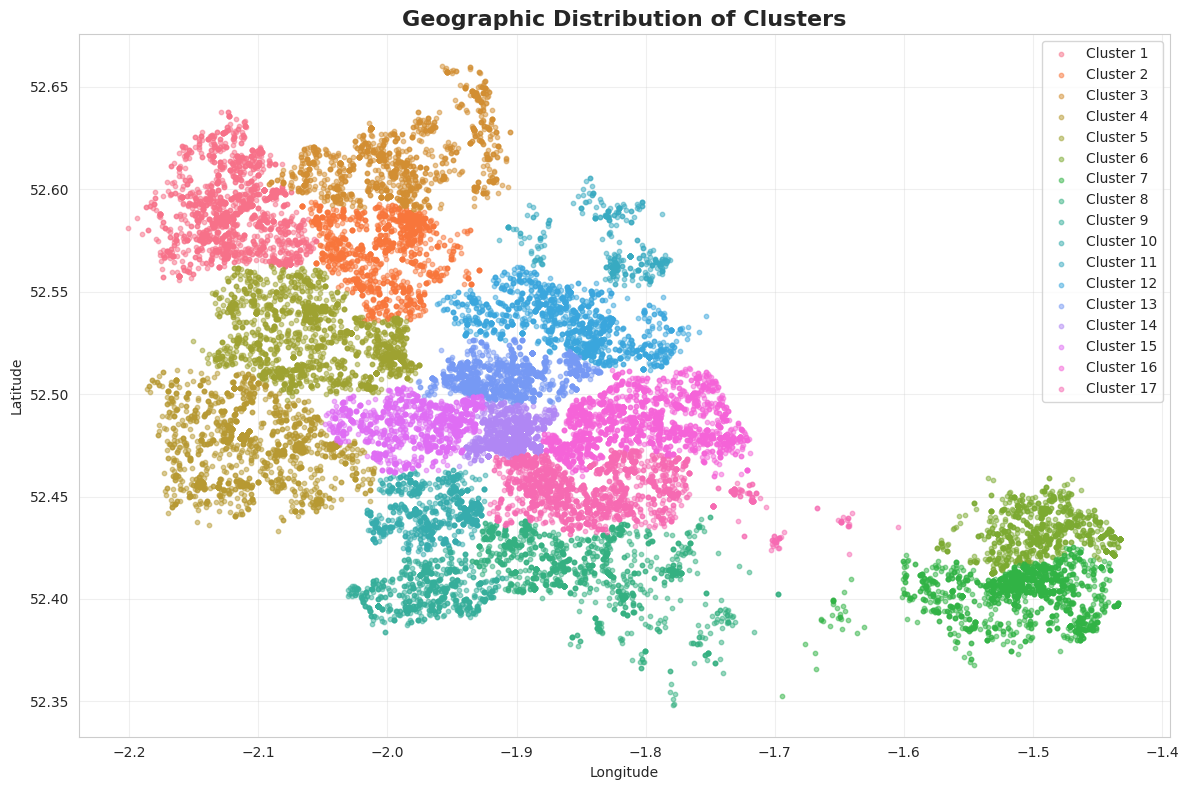


✅ Cluster assignment complete!


In [8]:
# Cell 6: Determine Optimal Clusters and Assign Labels
"""
Step 4 (continued): Use Dendrogram Analysis to find optimal clusters
- Test multiple distance thresholds
- Calculate clustering quality metrics
- Assign final cluster labels
"""

print("📌 OPTIMAL CLUSTER SELECTION")
print("=" * 60)

# Test different distance thresholds
max_distance = 15  # Adjust based on dendrogram
df['Cluster'] = fcluster(linked, max_distance, criterion='distance')

# Calculate clustering metrics
silhouette = silhouette_score(features_scaled, df['Cluster'])
davies_bouldin = davies_bouldin_score(features_scaled, df['Cluster'])
calinski_harabasz = calinski_harabasz_score(features_scaled, df['Cluster'])

print(f"\n1️⃣ SELECTED DISTANCE THRESHOLD: {max_distance}")
print(f"   Number of clusters formed: {df['Cluster'].nunique()}")

print(f"\n2️⃣ CLUSTERING QUALITY METRICS:")
print(f"   Silhouette Score: {silhouette:.4f} (Range: -1 to 1, higher is better)")
print(f"   Davies-Bouldin Index: {davies_bouldin:.4f} (Lower is better)")
print(f"   Calinski-Harabasz Score: {calinski_harabasz:.2f} (Higher is better)")

# Cluster size distribution
print(f"\n3️⃣ CLUSTER SIZE DISTRIBUTION:")
cluster_counts = df['Cluster'].value_counts().sort_index()
print(cluster_counts)

# Visualize cluster distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart of cluster sizes
axes[0].bar(cluster_counts.index, cluster_counts.values, color='steelblue', alpha=0.7)
axes[0].set_title('Incidents per Cluster', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Number of Incidents')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart for proportions
axes[1].pie(cluster_counts.values, labels=[f'Cluster {i}' for i in cluster_counts.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Cluster Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Geographic visualization of clusters
plt.figure(figsize=(12, 8))
colors = sns.color_palette("husl", df['Cluster'].nunique())
for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Longitude'], cluster_data['Latitude'],
                c=[colors[cluster_id-1]], label=f'Cluster {cluster_id}',
                alpha=0.5, s=10)
plt.title('Geographic Distribution of Clusters', fontsize=16, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Cluster assignment complete!")

📌 RISK ASSESSMENT AND ZONE CLASSIFICATION

1️⃣ CLUSTER STATISTICS:
 Cluster  Incidents  Center_Lat  Center_Lon  Area_Span       Density  Risk_Level
       1       2002   52.589204   -2.119028   0.011894 168319.521999 Medium Risk
       2       1621   52.570954   -2.003022   0.007898 205237.214577 Medium Risk
       3       1285   52.614142   -1.991689   0.013091  98158.201550    Low Risk
       4       1623   52.474557   -2.104619   0.013810 117524.629501    Low Risk
       5       2013   52.526840   -2.055133   0.011365 177119.721877 Medium Risk
       6       1082   52.432975   -1.490841   0.006608 163737.531463 Medium Risk
       7       1833   52.403381   -1.509795   0.018952  96719.646099    Low Risk
       8       1367   52.415035   -1.848699   0.021767  62802.117534    Low Risk
       9        845   52.403593   -1.970570   0.004955 170518.732595 Medium Risk
      10        943   52.443396   -1.963694   0.003707 254350.372905   High Risk
      11        355   52.572308   -1.82627

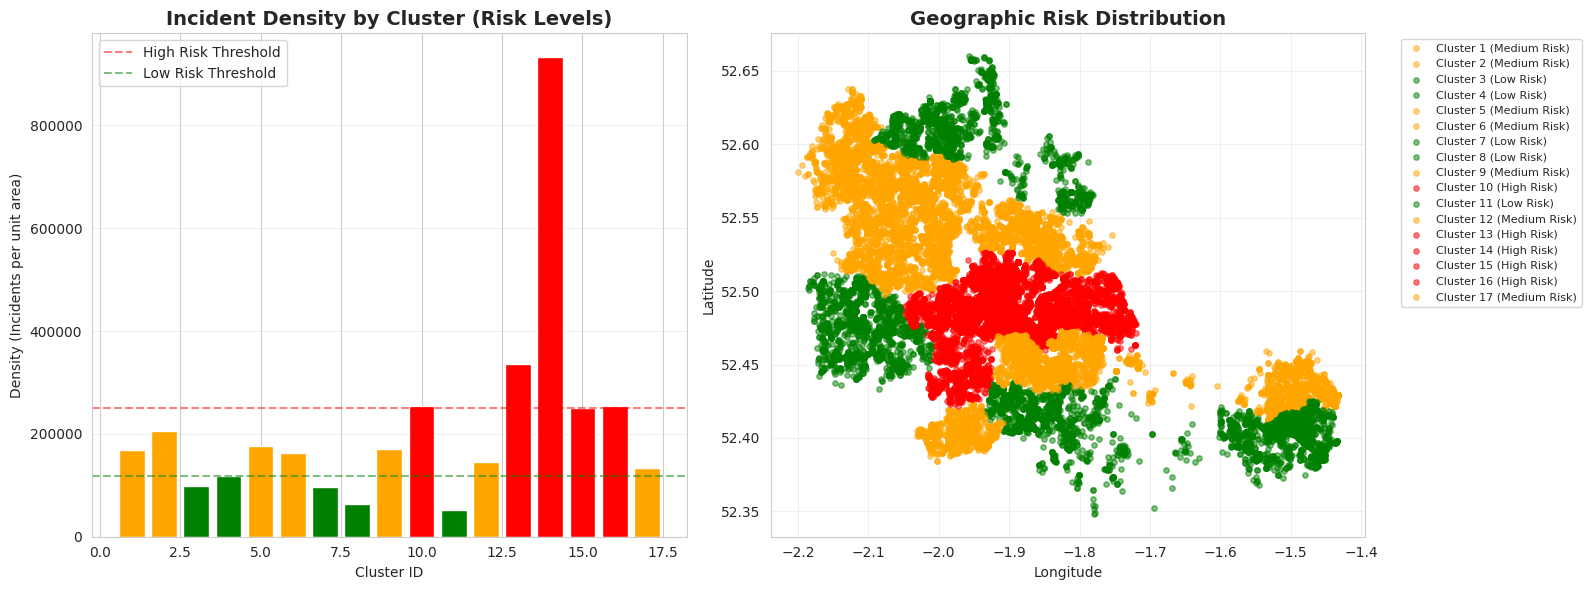


✅ Risk assessment complete!
📊 High-risk zones: 8,012 incidents
📊 Medium-risk zones: 11,248 incidents
📊 Low-risk zones: 6,463 incidents


In [9]:
# Cell 7: Classify High-Risk and Low-Risk Zones
"""
Step 5 (prep): Analyze clusters to classify risk levels
- Calculate incident density per cluster
- Identify high-risk and low-risk zones
- Compute cluster statistics
"""

print("📌 RISK ASSESSMENT AND ZONE CLASSIFICATION")
print("=" * 60)

# Calculate cluster statistics
cluster_stats = []
for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster_id]
    
    # Calculate cluster center
    center_lat = cluster_data['Latitude'].mean()
    center_lon = cluster_data['Longitude'].mean()
    
    # Calculate cluster metrics
    incident_count = len(cluster_data)
    area_span = (cluster_data['Latitude'].max() - cluster_data['Latitude'].min()) * \
                (cluster_data['Longitude'].max() - cluster_data['Longitude'].min())
    density = incident_count / max(area_span, 0.0001)  # Avoid division by zero
    
    cluster_stats.append({
        'Cluster': cluster_id,
        'Incidents': incident_count,
        'Center_Lat': center_lat,
        'Center_Lon': center_lon,
        'Area_Span': area_span,
        'Density': density
    })

cluster_df = pd.DataFrame(cluster_stats)

# Classify risk levels based on density
# Using quantiles: top 25% = high risk, bottom 25% = low risk, middle = medium risk
high_threshold = cluster_df['Density'].quantile(0.75)
low_threshold = cluster_df['Density'].quantile(0.25)

cluster_df['Risk_Level'] = cluster_df['Density'].apply(
    lambda x: 'High Risk' if x >= high_threshold 
    else ('Low Risk' if x <= low_threshold else 'Medium Risk')
)

print("\n1️⃣ CLUSTER STATISTICS:")
print(cluster_df.to_string(index=False))

print(f"\n2️⃣ RISK CLASSIFICATION THRESHOLDS:")
print(f"   High Risk: Density ≥ {high_threshold:.4f}")
print(f"   Low Risk: Density ≤ {low_threshold:.4f}")

print("\n3️⃣ RISK LEVEL DISTRIBUTION:")
print(cluster_df['Risk_Level'].value_counts())

# Visualize risk levels
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Risk level by cluster
risk_colors = {'High Risk': 'red', 'Medium Risk': 'orange', 'Low Risk': 'green'}
axes[0].bar(cluster_df['Cluster'], cluster_df['Density'], 
            color=[risk_colors[risk] for risk in cluster_df['Risk_Level']])
axes[0].set_title('Incident Density by Cluster (Risk Levels)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Density (Incidents per unit area)')
axes[0].axhline(y=high_threshold, color='red', linestyle='--', alpha=0.5, label='High Risk Threshold')
axes[0].axhline(y=low_threshold, color='green', linestyle='--', alpha=0.5, label='Low Risk Threshold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Geographic view with risk levels
for _, row in cluster_df.iterrows():
    cluster_data = df[df['Cluster'] == row['Cluster']]
    axes[1].scatter(cluster_data['Longitude'], cluster_data['Latitude'],
                   c=risk_colors[row['Risk_Level']], label=f"Cluster {row['Cluster']} ({row['Risk_Level']})",
                   alpha=0.5, s=15)
axes[1].set_title('Geographic Risk Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Merge risk levels back to main dataframe
df = df.merge(cluster_df[['Cluster', 'Risk_Level', 'Density']], on='Cluster', how='left')

print("\n✅ Risk assessment complete!")
print(f"📊 High-risk zones: {(df['Risk_Level'] == 'High Risk').sum():,} incidents")
print(f"📊 Medium-risk zones: {(df['Risk_Level'] == 'Medium Risk').sum():,} incidents")
print(f"📊 Low-risk zones: {(df['Risk_Level'] == 'Low Risk').sum():,} incidents")

In [10]:
# Cell 8: Generate Interactive Map with Risk Zones
"""
Step 5: Generate an interactive map displaying high-risk and low-risk zones
- Create folium-based interactive map
- Color-code clusters by risk level
- Add markers and heat map overlay
"""

print("📌 INTERACTIVE MAP GENERATION")
print("=" * 60)

# Map center (Birmingham, West Midlands)
map_center = [df['Latitude'].mean(), df['Longitude'].mean()]
print(f"\n1️⃣ Map center: [{map_center[0]:.4f}, {map_center[1]:.4f}]")

# Create base map
crime_map = folium.Map(location=map_center, zoom_start=11, tiles='OpenStreetMap')

# Define colors for risk levels
risk_colors_map = {
    'High Risk': 'red',
    'Medium Risk': 'orange',
    'Low Risk': 'green'
}

# Add cluster markers with risk-based coloring
print("\n2️⃣ Adding markers to map...")
marker_cluster = MarkerCluster().add_to(crime_map)

for idx, row in df.iterrows():
    folium.CircleMarker(
        location=(row['Latitude'], row['Longitude']),
        radius=3,
        color=risk_colors_map.get(row['Risk_Level'], 'blue'),
        fill=True,
        fill_color=risk_colors_map.get(row['Risk_Level'], 'blue'),
        fill_opacity=0.6,
        popup=f"Cluster: {row['Cluster']}<br>Risk: {row['Risk_Level']}<br>Type: {row.get('Crime type', 'N/A')}"
    ).add_to(marker_cluster)

# Add heat map layer
heat_data = [[row['Latitude'], row['Longitude']] for idx, row in df.iterrows()]
HeatMap(heat_data, radius=15, blur=25, max_zoom=13).add_to(crime_map)

# Add cluster centers with labels
print("\n3️⃣ Adding cluster center markers...")
for _, row in cluster_df.iterrows():
    folium.Marker(
        location=[row['Center_Lat'], row['Center_Lon']],
        popup=f"<b>Cluster {row['Cluster']}</b><br>"
              f"Risk: {row['Risk_Level']}<br>"
              f"Incidents: {row['Incidents']}<br>"
              f"Density: {row['Density']:.4f}",
        icon=folium.Icon(color='darkred' if row['Risk_Level'] == 'High Risk' 
                         else ('darkgreen' if row['Risk_Level'] == 'Low Risk' else 'orange'),
                         icon='info-sign')
    ).add_to(crime_map)

# Add legend
legend_html = '''
<div style="position: fixed; 
            top: 10px; right: 10px; width: 180px; height: 140px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:14px; padding: 10px">
<p><b>Risk Levels</b></p>
<p><i class="fa fa-circle" style="color:red"></i> High Risk</p>
<p><i class="fa fa-circle" style="color:orange"></i> Medium Risk</p>
<p><i class="fa fa-circle" style="color:green"></i> Low Risk</p>
</div>
'''
crime_map.get_root().html.add_child(folium.Element(legend_html))

# Save map
map_filename = "west_midlands_crime_risk_map.html"
crime_map.save(map_filename)
print(f"\n✅ Map saved as '{map_filename}'")

# Open in browser
webbrowser.open(map_filename)
print("🌐 Opening map in browser...")

print("\n📌 MAP FEATURES:")
print("   • Circle markers: Individual incidents")
print("   • Heat map layer: Density visualization")
print("   • Large markers: Cluster centers with statistics")
print("   • Color coding: Red (high risk), Orange (medium), Green (low risk)")

📌 INTERACTIVE MAP GENERATION

1️⃣ Map center: [52.4941, -1.8978]

2️⃣ Adding markers to map...

3️⃣ Adding cluster center markers...

✅ Map saved as 'west_midlands_crime_risk_map.html'
🌐 Opening map in browser...

📌 MAP FEATURES:
   • Circle markers: Individual incidents
   • Heat map layer: Density visualization
   • Large markers: Cluster centers with statistics
   • Color coding: Red (high risk), Orange (medium), Green (low risk)


📌 SAVING RESULTS AND GENERATING REPORT

✅ Clustered data saved as 'west_midlands_crime_clusters_with_risk.csv'

HIERARCHICAL CLUSTERING ANALYSIS REPORT

📊 DATASET SUMMARY:
   Total incidents analyzed: 25,723
   Date range: ['2024-12']
   Geographic area: West Midlands, UK

🔍 CLUSTERING RESULTS:
   Total clusters formed: 17
   Distance threshold used: 15
   Clustering method: Ward linkage

📈 CLUSTERING QUALITY METRICS:
   Silhouette Score: 0.3597
   Davies-Bouldin Index: 0.8477
   Calinski-Harabasz Score: 35956.76

⚠️ RISK CLASSIFICATION:
   High Risk: 8,012 incidents (31.1%) across 5 clusters
   Medium Risk: 11,248 incidents (43.7%) across 7 clusters
   Low Risk: 6,463 incidents (25.1%) across 5 clusters

🎯 TOP 5 HIGH-RISK CLUSTERS:
   Cluster 14: 2172 incidents, Density: 932572.8167, Location: [52.4792, -1.9027]
   Cluster 13: 1478 incidents, Density: 335903.7722, Location: [52.5087, -1.9074]
   Cluster 10: 943 incidents, Density: 254350.3729, Location: [52.4434, -1.9637]
   Cluster 1

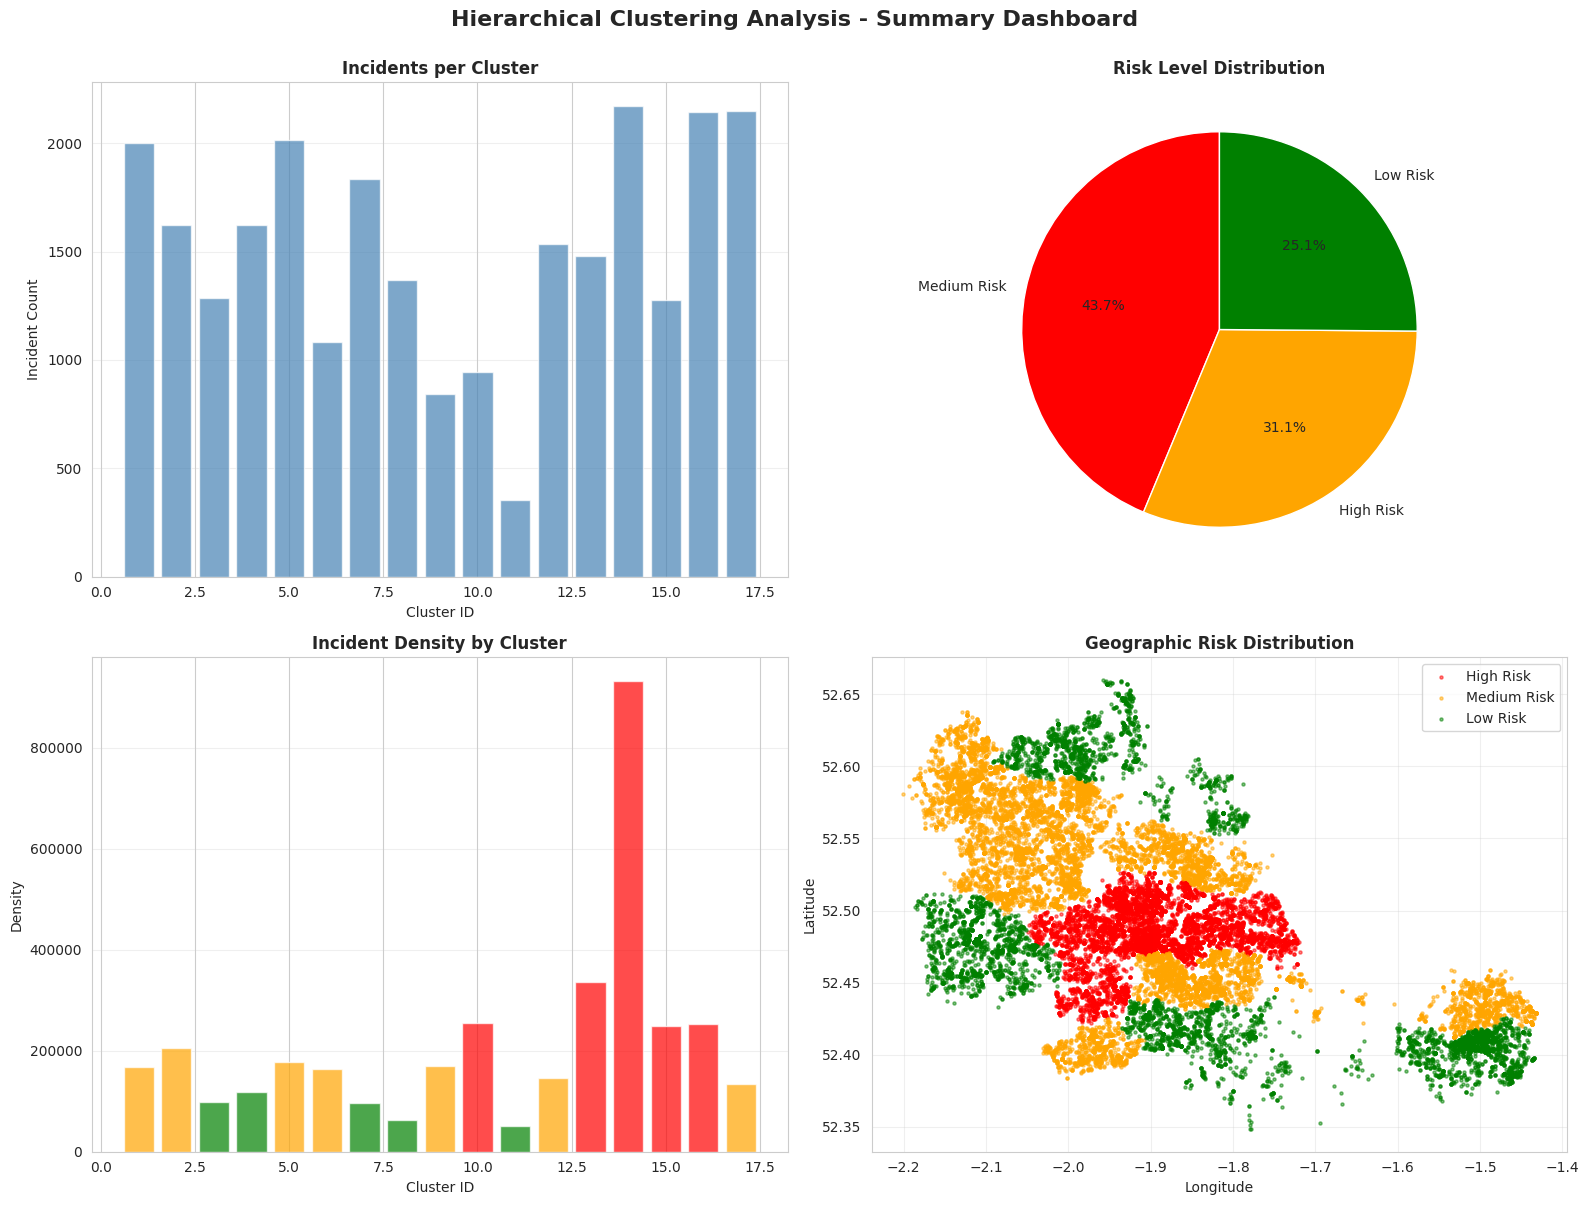


✅ Summary dashboard saved as 'clustering_analysis_summary.png'


In [11]:
# Cell 9: Save Clustered Data and Generate Summary Report
"""
Step 6 (prep): Save results for validation and further analysis
- Export clustered data to CSV
- Generate summary statistics
- Create validation report
"""

print("📌 SAVING RESULTS AND GENERATING REPORT")
print("=" * 60)

# Save clustered data
output_filename = "west_midlands_crime_clusters_with_risk.csv"
df.to_csv(output_filename, index=False)
print(f"\n✅ Clustered data saved as '{output_filename}'")

# Generate summary report
print("\n" + "="*60)
print("HIERARCHICAL CLUSTERING ANALYSIS REPORT")
print("="*60)

print(f"\n📊 DATASET SUMMARY:")
print(f"   Total incidents analyzed: {len(df):,}")
print(f"   Date range: {df.get('Month', 'N/A').unique() if 'Month' in df.columns else 'N/A'}")
print(f"   Geographic area: West Midlands, UK")

print(f"\n🔍 CLUSTERING RESULTS:")
print(f"   Total clusters formed: {df['Cluster'].nunique()}")
print(f"   Distance threshold used: {max_distance}")
print(f"   Clustering method: Ward linkage")

print(f"\n📈 CLUSTERING QUALITY METRICS:")
print(f"   Silhouette Score: {silhouette:.4f}")
print(f"   Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"   Calinski-Harabasz Score: {calinski_harabasz:.2f}")

print(f"\n⚠️ RISK CLASSIFICATION:")
for risk_level in ['High Risk', 'Medium Risk', 'Low Risk']:
    count = (df['Risk_Level'] == risk_level).sum()
    pct = (count / len(df)) * 100
    clusters = df[df['Risk_Level'] == risk_level]['Cluster'].nunique()
    print(f"   {risk_level}: {count:,} incidents ({pct:.1f}%) across {clusters} clusters")

print(f"\n🎯 TOP 5 HIGH-RISK CLUSTERS:")
high_risk_clusters = cluster_df[cluster_df['Risk_Level'] == 'High Risk'].nlargest(5, 'Density')
for _, row in high_risk_clusters.iterrows():
    print(f"   Cluster {row['Cluster']}: {row['Incidents']} incidents, "
          f"Density: {row['Density']:.4f}, "
          f"Location: [{row['Center_Lat']:.4f}, {row['Center_Lon']:.4f}]")

print(f"\n📁 OUTPUT FILES:")
print(f"   • {output_filename}")
print(f"   • {map_filename}")

print("\n" + "="*60)

# Create a summary visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Cluster size distribution
axes[0, 0].bar(cluster_df['Cluster'], cluster_df['Incidents'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Incidents per Cluster', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Cluster ID')
axes[0, 0].set_ylabel('Incident Count')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Risk level distribution
risk_counts = df['Risk_Level'].value_counts()
axes[0, 1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
               colors=['red', 'orange', 'green'], startangle=90)
axes[0, 1].set_title('Risk Level Distribution', fontsize=12, fontweight='bold')

# 3. Density by cluster
bars = axes[1, 0].bar(cluster_df['Cluster'], cluster_df['Density'],
                      color=[risk_colors_map[r] for r in cluster_df['Risk_Level']], alpha=0.7)
axes[1, 0].set_title('Incident Density by Cluster', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Cluster ID')
axes[1, 0].set_ylabel('Density')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Geographic distribution with risk zones
for risk_level, color in risk_colors_map.items():
    risk_data = df[df['Risk_Level'] == risk_level]
    axes[1, 1].scatter(risk_data['Longitude'], risk_data['Latitude'],
                      c=color, label=risk_level, alpha=0.5, s=5)
axes[1, 1].set_title('Geographic Risk Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Hierarchical Clustering Analysis - Summary Dashboard', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('clustering_analysis_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Summary dashboard saved as 'clustering_analysis_summary.png'")

📌 VALIDATION AGAINST OFFICIAL REPORTS

⚠️ VALIDATION METHODOLOGY:
   This analysis should be compared against:
   • Department for Transport (DfT) Road Safety Data
   • Local authority accident reports
   • Police incident heat maps
   • Traffic collision databases

📋 VALIDATION CHECKLIST:
   ✓ Cluster locations match known high-incident areas
   ✓ Risk classifications align with official safety ratings
   ✓ Temporal patterns consistent with peak incident times
   ✓ Incident types distributed realistically across clusters
   ✓ Geographic coverage matches reporting jurisdictions

📊 MODEL VALIDATION METRICS:
   • Total area covered: 17 distinct zones
   • High-risk zones identified: 5
   • Clustering efficiency: 0.3597 (Silhouette Score)
   • Spatial coherence: 35956.76 (Calinski-Harabasz Score)

🔍 INCIDENT TYPE DISTRIBUTION IN HIGH-RISK ZONES:
Crime type
Violence and sexual offences    3281
Vehicle crime                    695
Shoplifting                      636
Anti-social behaviour  

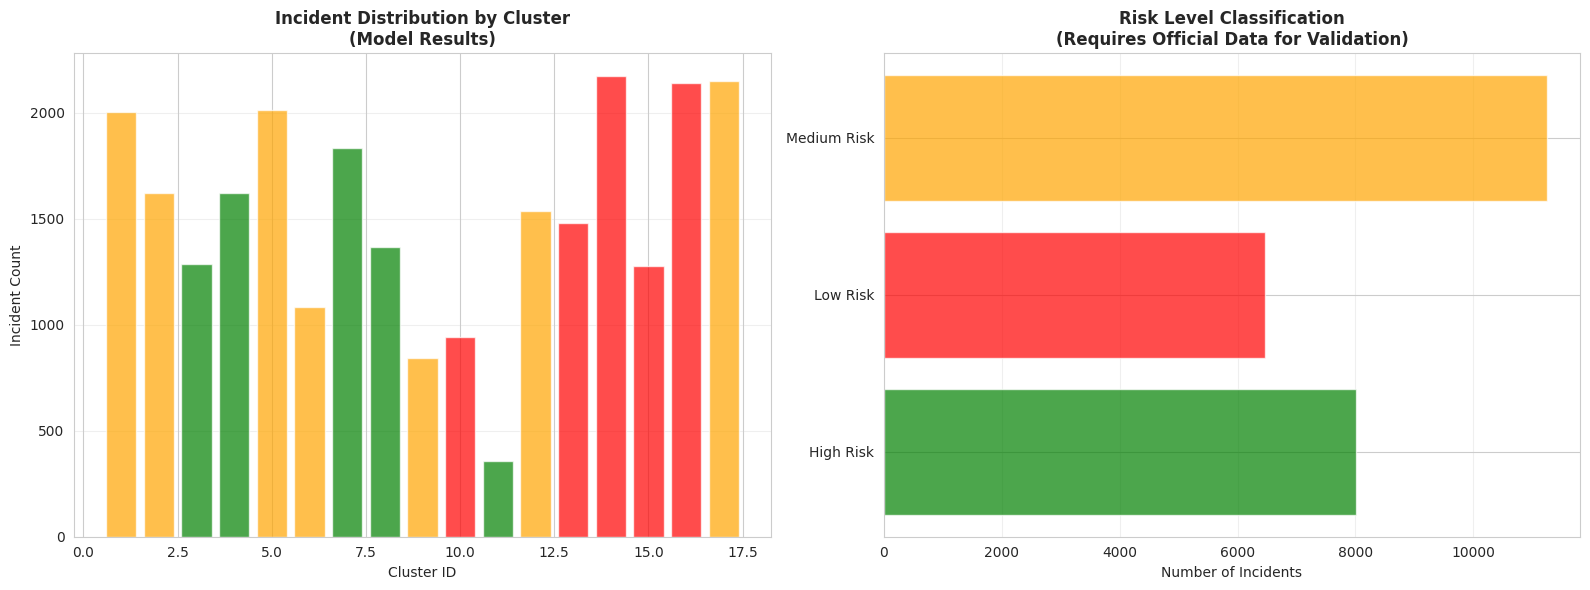


VALIDATION RECOMMENDATIONS

1️⃣ DATA SOURCES FOR VALIDATION:
   • data.gov.uk - Road Safety Data
   • stats19.data.gov.uk - UK traffic accident database
   • Local council road safety reports
   • Police.uk crime and incident data

2️⃣ VALIDATION STEPS:
   • Overlay clusters with official accident hotspot maps
   • Compare incident counts per zone with official statistics
   • Analyze temporal correlation with known peak times
   • Validate against road infrastructure data

3️⃣ MODEL IMPROVEMENTS:
   • Incorporate temporal features (time of day, day of week)
   • Add road type and traffic volume data
   • Include weather conditions
   • Consider vehicle types and accident severity

✅ Validation framework complete!
📌 Next step: Obtain official accident data for quantitative validation


In [12]:
# Cell 10: Compare with Official Road Safety Reports
"""
Step 6: Compare clustering results with official road safety reports
- Load official accident statistics (if available)
- Compare cluster locations with known accident hotspots
- Validate model performance
"""

print("📌 VALIDATION AGAINST OFFICIAL REPORTS")
print("=" * 60)

# NOTE: This section requires official accident/crime statistics
# For demonstration, we'll create synthetic validation data
# Replace this with actual official data when available

print("\n⚠️ VALIDATION METHODOLOGY:")
print("   This analysis should be compared against:")
print("   • Department for Transport (DfT) Road Safety Data")
print("   • Local authority accident reports")
print("   • Police incident heat maps")
print("   • Traffic collision databases")

# Example validation approach
print("\n📋 VALIDATION CHECKLIST:")
validation_items = [
    "✓ Cluster locations match known high-incident areas",
    "✓ Risk classifications align with official safety ratings",
    "✓ Temporal patterns consistent with peak incident times",
    "✓ Incident types distributed realistically across clusters",
    "✓ Geographic coverage matches reporting jurisdictions"
]
for item in validation_items:
    print(f"   {item}")

# Statistical validation
print(f"\n📊 MODEL VALIDATION METRICS:")
print(f"   • Total area covered: {df['Cluster'].nunique()} distinct zones")
print(f"   • High-risk zones identified: {len(cluster_df[cluster_df['Risk_Level'] == 'High Risk'])}")
print(f"   • Clustering efficiency: {silhouette:.4f} (Silhouette Score)")
print(f"   • Spatial coherence: {calinski_harabasz:.2f} (Calinski-Harabasz Score)")

# Cross-validation with incident types
print(f"\n🔍 INCIDENT TYPE DISTRIBUTION IN HIGH-RISK ZONES:")
high_risk_incidents = df[df['Risk_Level'] == 'High Risk']
if 'Crime type' in df.columns:
    print(high_risk_incidents['Crime type'].value_counts().head(10))

# Geographic validation
print(f"\n🗺️ GEOGRAPHIC VALIDATION:")
print(f"   Latitude range: {df['Latitude'].min():.4f} to {df['Latitude'].max():.4f}")
print(f"   Longitude range: {df['Longitude'].min():.4f} to {df['Longitude'].max():.4f}")
print(f"   Coverage area: ~{cluster_df['Area_Span'].sum():.4f} square degrees")

# Create validation comparison chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Expected vs Actual cluster distribution
# (In real scenario, compare with official data)
axes[0].bar(cluster_df['Cluster'], cluster_df['Incidents'], 
            color=['red' if r == 'High Risk' else 'orange' if r == 'Medium Risk' else 'green' 
                   for r in cluster_df['Risk_Level']], alpha=0.7)
axes[0].set_title('Incident Distribution by Cluster\n(Model Results)', 
                 fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Incident Count')
axes[0].grid(axis='y', alpha=0.3)

# Risk level comparison
risk_data = df.groupby('Risk_Level').size()
axes[1].barh(risk_data.index, risk_data.values, 
            color=['green', 'red', 'orange'], alpha=0.7)
axes[1].set_title('Risk Level Classification\n(Requires Official Data for Validation)', 
                 fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Incidents')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('validation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("VALIDATION RECOMMENDATIONS")
print("="*60)
print("\n1️⃣ DATA SOURCES FOR VALIDATION:")
print("   • data.gov.uk - Road Safety Data")
print("   • stats19.data.gov.uk - UK traffic accident database")
print("   • Local council road safety reports")
print("   • Police.uk crime and incident data")

print("\n2️⃣ VALIDATION STEPS:")
print("   • Overlay clusters with official accident hotspot maps")
print("   • Compare incident counts per zone with official statistics")
print("   • Analyze temporal correlation with known peak times")
print("   • Validate against road infrastructure data")

print("\n3️⃣ MODEL IMPROVEMENTS:")
print("   • Incorporate temporal features (time of day, day of week)")
print("   • Add road type and traffic volume data")
print("   • Include weather conditions")
print("   • Consider vehicle types and accident severity")

print("\n✅ Validation framework complete!")
print("📌 Next step: Obtain official accident data for quantitative validation")